# K-Means Clustering: Iris Dataset

1. **Iris** — a real dataset with ground-truth labels, so we can check whether the clusters
   K-means finds actually line up with the real species

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, load_iris, load_sample_image
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

In [15]:
# load the iris dataset
iris = load_iris()
print('Iris', iris.data)

Iris [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3

In [16]:
X_iris, y_iris_true = iris.data, iris.target

# Standardize: petal/sepal measurements are on different scales, and K-means is
# distance-based, so unscaled features would let large-magnitude ones dominate.
X_iris_scaled = StandardScaler().fit_transform(X_iris)

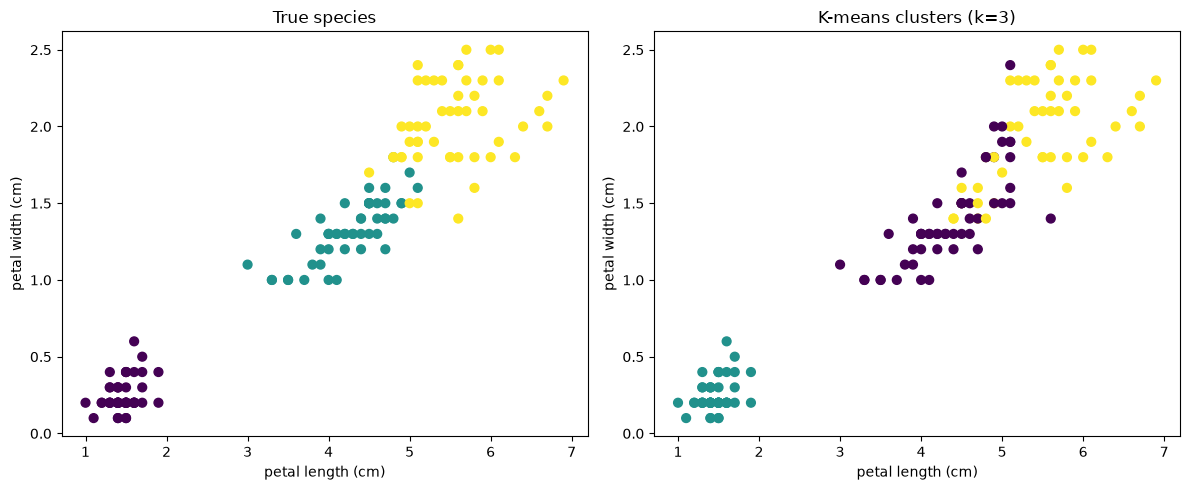

Silhouette score: 0.460


In [17]:
kmeans_iris = KMeans(n_clusters=3, random_state=42, n_init=10)
y_iris_pred = kmeans_iris.fit_predict(X_iris_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_iris[:, 2], X_iris[:, 3], c=y_iris_true, cmap="viridis", s=40)
axes[0].set_title("True species")
axes[0].set_xlabel("petal length (cm)")
axes[0].set_ylabel("petal width (cm)")

axes[1].scatter(X_iris[:, 2], X_iris[:, 3], c=y_iris_pred, cmap="viridis", s=40)
axes[1].set_title("K-means clusters (k=3)")
axes[1].set_xlabel("petal length (cm)")
axes[1].set_ylabel("petal width (cm)")

plt.tight_layout()
plt.show()

print(f"Silhouette score: {silhouette_score(X_iris_scaled, y_iris_pred):.3f}")

- K-means recovers one species (setosa) almost perfectly since it's clearly
separated in petal measurements, but the boundary between the other two (versicolor and
virginica) doesn't match the true species split exactly.

### Choosing k: Elbow method

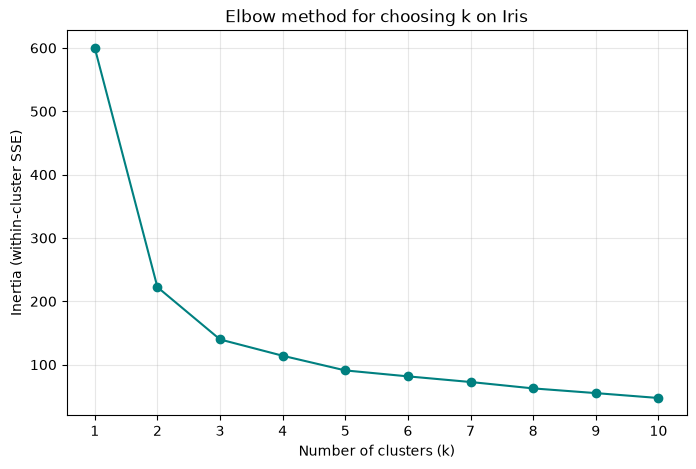

In [18]:
inertias = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_iris_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertias, "o-", color="teal")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow method for choosing k on Iris")
plt.xticks(K)
plt.grid(alpha=0.3)
plt.show()

- The curve bends sharply around `k=3`, so the elbow method points to `k=3` — matching the true number of Iris species.

### Choosing k: Silhouette score method

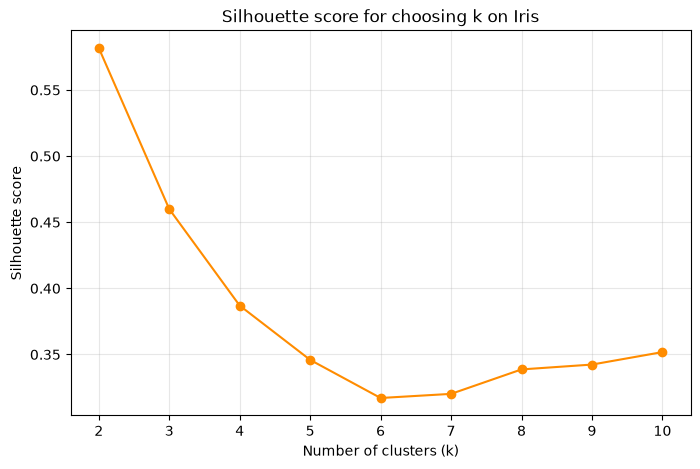

In [19]:
silhouettes = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    y_pred = kmeans.fit_predict(X_iris_scaled)
    silhouettes.append(silhouette_score(X_iris_scaled, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(K, silhouettes, "o-", color="darkorange")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for choosing k on Iris")
plt.xticks(K)
plt.grid(alpha=0.3)
plt.show()

- The silhouette score peaks at `k=2` and comes in second at `k=3`.
- This shows the two methods can disagree, and the silhouette score is best used together with the elbow method (and domain knowledge) rather than as a standalone answer.

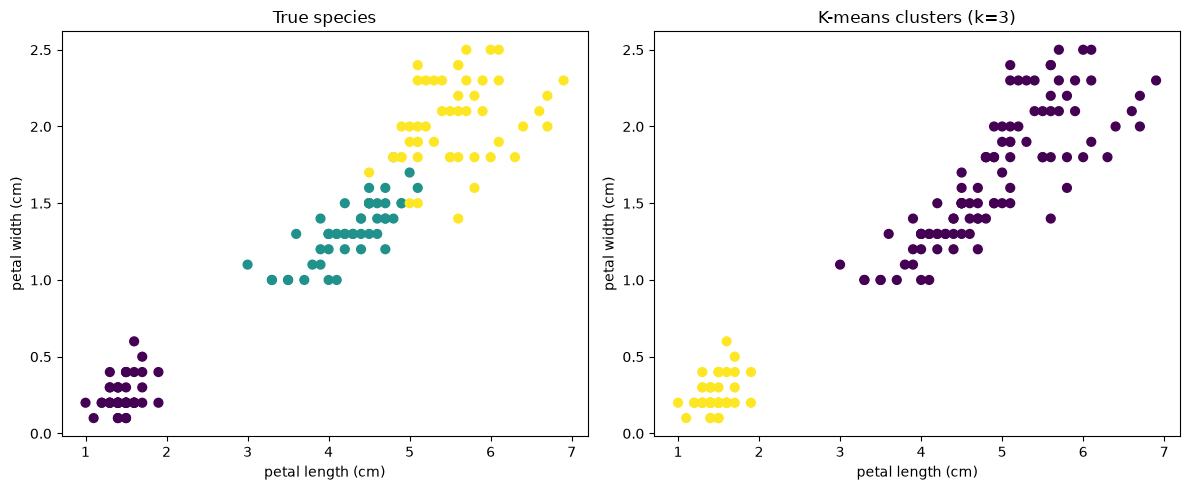

Silhouette score: 0.582


In [20]:
kmeans_iris = KMeans(n_clusters=2, random_state=42, n_init=10)
y_iris_pred = kmeans_iris.fit_predict(X_iris_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_iris[:, 2], X_iris[:, 3], c=y_iris_true, cmap="viridis", s=40)
axes[0].set_title("True species")
axes[0].set_xlabel("petal length (cm)")
axes[0].set_ylabel("petal width (cm)")

axes[1].scatter(X_iris[:, 2], X_iris[:, 3], c=y_iris_pred, cmap="viridis", s=40)
axes[1].set_title("K-means clusters (k=3)")
axes[1].set_xlabel("petal length (cm)")
axes[1].set_ylabel("petal width (cm)")

plt.tight_layout()
plt.show()

print(f"Silhouette score: {silhouette_score(X_iris_scaled, y_iris_pred):.3f}")